# Testing
## Todesfälle nach Monat, Stadtquartier, Geschlecht, Altersgruppe und Herkunft, seit 1998
Datum: 21.01.2022

### Importiere die notwendigen Packages

In [1]:
import pandas as pd
import pivottablejs
from pivottablejs import pivot_ui
import numpy as np
import altair as alt
import matplotlib.pyplot as plt
#from datetime import datetime
import datetime
from dateutil.relativedelta import *
import geopandas as gpd
import folium 
import plotly.express as px


ModuleNotFoundError: No module named 'pivottablejs'

Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [ ]:
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

### Zeitvariabeln
Bestimme den aktuellst geladenen Monat. Hier ist es der Stand vor 2 Monaten. 
Bestimme noch weitere evt. sinnvolle Zeitvariabeln.

Zum Unterschied zwischen import datetime und from datedtime import datetime, siehe https://stackoverflow.com/questions/15707532/import-datetime-v-s-from-datetime-import-datetime

#### Zuerst die generellen Zeitvariabeln als Strings

In [ ]:
#today_date = datetime.date.today()
#date_time = datetime.datetime.strptime(date_time_string, '%Y-%m-%d %H:%M')
now = datetime.date.today()
date_today = now.strftime("%Y-%m-%d")
year_today = now.strftime("%Y")
year_month_today = now.strftime("%Y-%m")
month_today = now.strftime("%Y")
day_today = now.strftime("%d")

#### Die zu testenden Zeitvariabeln als Strings

Hier mal die folgenden:
- `latest_year_month`: Der aktuellste Datenstand sollte ja immer der heutige Monat minus 2 sein.
- `latest_year`: Der aktuellste Datenstand sollte ja immer der heutige Monat minus 2 sein. Hier wird das damalige Jahr angegeben.
- `five_years_ago`: Und damit nicht immer alle Zeitreihen geprüft werden müssen, kann auch das Jahr vor 5 Jahren definiert werden.

In [ ]:
#from datetime import datetime, timedelta
#from dateutil.relativedelta import *

latest_year_month = now + relativedelta(months=-2)
latest_year_month = latest_year_month.strftime("%Y-%m")
print(latest_year_month)

latest_year = now + relativedelta(months=-2)
latest_year = latest_year.strftime("%Y")
print(latest_year)

five_years_ago  = now + relativedelta(years=-5)
five_years_ago = five_years_ago.strftime("%Y")
print(five_years_ago)

2025-04
2025
2020


#### Und hier noch die Zeitvariabeln als Integers:
- `aktuellesJahr`
- `aktuellerMonat`: Der gerade jetzt aktuelle Monat
- `selectedMonat`: Der aktuellste Monat in den Daten. In der Regel zwei Monate her.

In [ ]:
#now = datetime.now() 
int_times = now.timetuple()

aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2

print(aktuellesJahr, 
      aktuellerMonat,
    'datenstand: ', selectedMonat,
     int_times)


2025 6 datenstand:  4 time.struct_time(tm_year=2025, tm_mon=6, tm_mday=13, tm_hour=0, tm_min=0, tm_sec=0, tm_wday=4, tm_yday=164, tm_isdst=-1)


Berechne die Variable Epoche um später das SAS-Datum in ein Unix-Datum umzuwandeln. Bei SAS beginnt die Epoche am 1.1.1960. Bei Unix am 1.1.1970.
Diese Variable wird beim CSV-Import benötigt.

In [ ]:
epoch = datetime.datetime(1960, 1, 1)

### Importiere einen Datensatz 

- Beachte dabei die Notation des Pfades...
- Definiere mal aktuell noch keine weiteren Parameter beim Import

**Dataset auf INTEG Datenkatalog**:  https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_todesfaelle_quartier_geschl_ag_herkunft_od4210

**Dataset auf PROD Datenkatalog**:  https://data.stadt-zuerich.ch/dataset/bev_monat_todesfaelle_quartier_geschl_ag_herkunft_od4210

In [ ]:
#Die Datasets sind nur zum Testen auf INT-DWH-Dropzone. Wenn der Test vorbei ist, sind sie auf PROD. 
# Über den Status kann man einfach switchen

status = "int";
print(status)

int


In [ ]:
# Filepath
if status == "prod":
    #fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/DWH/bev_monat_bestand_quartier_geschl_ag_herkunft_od3250/BEV325OD3250.csv"
    fp = r"https://data.stadt-zuerich.ch/dataset/bev_monat_todesfaelle_quartier_geschl_ag_herkunft_od4210/download/BEV421OD4210.csv"
else:
    #fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/INT_DWH/bev_tag_todesfaelle_quartier_geschl_ag_herkunft_od4211/BEV421OD4211.csv" #tag todesfälle
    #fp = r"\\szh\ssz\applikationen\OGD_Dropzone\INT_DWH\bev_tag_geburten_quartier_geschl_ag_herkunft_od4031\BEV403OD4031.csv" #tag geburten
    #fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/INT_DWH/bev_monat_todesfaelle_quartier_geschl_ag_herkunft_od4210/BEV421OD4210.csv"    
    fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/INT_DWH/bev_monat_todesfaelle_quartier_geschl_ag_herkunft_od4210/BEV421OD4210.csv"
    #fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/INT_DWH/bev_monat_geburten_quartier_geschl_ag_herkunft_od4030/BEV403OD4030.csv"
    #fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/INT_DWH/bev_monat_zuz_quartier_geschl_ag_herkunft_od3530/BEV353OD3530.csv"    
    #fp = r"//szh.loc/ssz/applikationen/OGD_Dropzone/INT_DWH/bev_monat_wegz_quartier_geschl_ag_herkunft_od3540/BEV354OD3540.csv"
print(fp)

//szh.loc/ssz/applikationen/OGD_Dropzone/INT_DWH/bev_monat_todesfaelle_quartier_geschl_ag_herkunft_od4210/BEV421OD4210.csv


Beachte, wie das SAS Datum (ohne Format) in ein UNIX Datum umgerechnet und als Datumsformat dargestellt wird! Siehe dazu `https://stackoverflow.com/questions/26923564/convert-sas-numeric-to-python-datetime`

Achtung: seit Juni 2023 nicht mehr notwendig, da die Daten nun korrekt als ISO 8401 geliefert werden.

In [ ]:
# Read the data
data2betested = pd.read_csv(
    fp, 
    sep=',',
    parse_dates=['StichtagDat'],
    # KONVERTIERE DAS SAS DATUM IN EIN UNIXDATUM UND FORMATIERE ES
    #date_parser=lambda s: epoch + datetime.timedelta(days=int(s)),
    low_memory=False    
    )

print('done')

done


In [ ]:
latest_data_month = data2betested.reset_index().StichtagDat.max()
str_latest_data_month= str(latest_data_month)
print("Der aktuellste Monat im Datensatz ist: "+ str_latest_data_month)

Der aktuellste Monat im Datensatz ist: 2025-04-30 00:00:00


In der Folge ein paar erste Tests:

 - 1) Zeige eine kurze Vorschau der importierten Daten
 - 2) Weise die Datentypen aus
 - 3) Zeige die Shape (Umfang) des Datensatzes an

In [ ]:
data2betested.sort_values(by=['EreignisDatJahr','EreignisDatMM'], ascending=False).head(3)
#data2betested.head(6)

,EreignisDatJahr,EreignisDatMM,EreignisDatMonat,StichtagDat,SexCd,SexLang,AlterV20Sort,...,KreisCd,KreisLang,QuarCd,QuarLang,DatenstandCd,DatenstandLang,AnzSterWir
44809,2025,4,April,2025-04-30,1,männlich,2,...,9,Kreis 9,92,Altstetten,P,Provisorisch,1
44810,2025,4,April,2025-04-30,1,männlich,3,...,7,Kreis 7,74,Witikon,P,Provisorisch,1
44811,2025,4,April,2025-04-30,1,männlich,3,...,9,Kreis 9,92,Altstetten,P,Provisorisch,1


In [ ]:
data2betested.dtypes

EreignisDatJahr              int64
EreignisDatMM                int64
EreignisDatMonat            object
StichtagDat         datetime64[ns]
SexCd                        int64
SexLang                     object
AlterV20Sort                 int64
AlterV20Kurz                object
HerkunftCd                   int64
HerkunftLang                object
KreisCd                      int64
KreisLang                   object
QuarCd                       int64
QuarLang                    object
DatenstandCd                object
DatenstandLang              object
AnzSterWir                   int64
dtype: object

In [ ]:
data2betested.shape

(44923, 17)

Beschreibe einzelne Attribute

In [ ]:
data2betested.describe()

,EreignisDatJahr,EreignisDatMM,StichtagDat,SexCd,AlterV20Sort,HerkunftCd,KreisCd,QuarCd,AnzSterWir
count,44923,44923,44923,44923,44923,44923,44923,44923,44923
mean,2011,6,2011-06-03 15:16:17.272221440,1,4,1,7,73,2
min,1998,1,1998-01-31 00:00:00,1,1,1,1,11,1
25%,2004,3,2004-06-30 00:00:00,1,4,1,4,41,1
50%,2011,6,2011-04-30 00:00:00,1,4,1,7,73,1
75%,2018,9,2018-04-30 00:00:00,2,5,1,10,102,3
max,2025,12,2025-04-30 00:00:00,2,6,2,12,123,29
std,8,4,NaN,0,1,0,3,34,2


Wie viele Nullwerte gibt es im Datensatz?

In [ ]:
data2betested.isnull().sum()

EreignisDatJahr     0
EreignisDatMM       0
EreignisDatMonat    0
StichtagDat         0
SexCd               0
SexLang             0
AlterV20Sort        0
AlterV20Kurz        0
HerkunftCd          0
HerkunftLang        0
KreisCd             0
KreisLang           0
QuarCd              0
QuarLang            0
DatenstandCd        0
DatenstandLang      0
AnzSterWir          0
dtype: int64

### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [ ]:
data2betested = data2betested.set_index("StichtagDat")
#data2betested = data2betested.drop(columns=["StichtagDatMM"])

In [ ]:
data2betested.info()
data2betested.index.day.unique()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 44923 entries, 1998-01-31 to 2025-04-30
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   EreignisDatJahr   44923 non-null  int64 
 1   EreignisDatMM     44923 non-null  int64 
 2   EreignisDatMonat  44923 non-null  object
 3   SexCd             44923 non-null  int64 
 4   SexLang           44923 non-null  object
 5   AlterV20Sort      44923 non-null  int64 
 6   AlterV20Kurz      44923 non-null  object
 7   HerkunftCd        44923 non-null  int64 
 8   HerkunftLang      44923 non-null  object
 9   KreisCd           44923 non-null  int64 
 10  KreisLang         44923 non-null  object
 11  QuarCd            44923 non-null  int64 
 12  QuarLang          44923 non-null  object
 13  DatenstandCd      44923 non-null  object
 14  DatenstandLang    44923 non-null  object
 15  AnzSterWir        44923 non-null  int64 
dtypes: int64(8), object(8)
memory usage: 5.8+

Index([31, 28, 30, 29], dtype='int32', name='StichtagDat')

### Einfache Visualisierungen zur Plausi

Exploriere die Daten mit Pivottable.JS

In [ ]:
from pivottablejs import pivot_ui

#pivot_ui(data2betested)

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [ ]:
data2betested.loc[latest_year_month].head(4)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,EreignisDatJahr,EreignisDatMM,EreignisDatMonat,SexCd,SexLang,AlterV20Sort,AlterV20Kurz,...,KreisCd,KreisLang,QuarCd,QuarLang,DatenstandCd,DatenstandLang,AnzSterWir
StichtagDat,,,,,,,,,,,,,,,
2025-04-30,2025,4,April,1,männlich,2,20-39,...,9,Kreis 9,92,Altstetten,P,Provisorisch,1
2025-04-30,2025,4,April,1,männlich,3,40-59,...,7,Kreis 7,74,Witikon,P,Provisorisch,1
2025-04-30,2025,4,April,1,männlich,3,40-59,...,9,Kreis 9,92,Altstetten,P,Provisorisch,1
2025-04-30,2025,4,April,1,männlich,3,40-59,...,10,Kreis 10,101,Höngg,P,Provisorisch,1


### Aggregiere Werte nach Zeitausschnitten

Mit den Funktionen zur Zeit kann einfach zwischen Stunden, Tagen, Monaten, etc. gewechselt und aggregiert werden.
Da die Daten bereits aggregiert nach Monaten sind, macht das hier keinen Sinn.
Untenstehendes also nur als BSP


In [ ]:
# first we create the sums per week
weekly_sums = data2betested.resample("W").sum()
# then we generate the weekly means for each quarter
data2betested_sel = data2betested[["SexCd","HerkunftCd","AnzSterWir"]]
quarterly_sums = data2betested_sel.resample("Q").sum()
# for readability we'll revert the values back to integers
quarterly_sums.astype(int).head(1)

C:\Users\sszsim\AppData\Local\Temp\ipykernel_3504\120138807.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_sums = data2betested_sel.resample("Q").sum()


,SexCd,HerkunftCd,AnzSterWir
StichtagDat,,,
1998-03-31,691,551,1117


### Visualisierungen nach Zeitausschnitten

In [ ]:
data2betested.info()
#data2betested

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 44923 entries, 1998-01-31 to 2025-04-30
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   EreignisDatJahr   44923 non-null  int64 
 1   EreignisDatMM     44923 non-null  int64 
 2   EreignisDatMonat  44923 non-null  object
 3   SexCd             44923 non-null  int64 
 4   SexLang           44923 non-null  object
 5   AlterV20Sort      44923 non-null  int64 
 6   AlterV20Kurz      44923 non-null  object
 7   HerkunftCd        44923 non-null  int64 
 8   HerkunftLang      44923 non-null  object
 9   KreisCd           44923 non-null  int64 
 10  KreisLang         44923 non-null  object
 11  QuarCd            44923 non-null  int64 
 12  QuarLang          44923 non-null  object
 13  DatenstandCd      44923 non-null  object
 14  DatenstandLang    44923 non-null  object
 15  AnzSterWir        44923 non-null  int64 
dtypes: int64(8), object(8)
memory usage: 5.8+

#### Entwicklung Sterbefälle nach Stadtkreis

In [ ]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg = data2betested \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM','KreisLang']) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values('StichtagDat', ascending=True) 

myAgg.reset_index().head(3)

,StichtagDat,EreignisDatJahr,EreignisDatMM,KreisLang,sum_WBev
0,1998-01-31,1998,1,Kreis 1,2
1,1998-01-31,1998,1,Kreis 9,36
2,1998-01-31,1998,1,Kreis 8,13


In [ ]:
myTitle ="Todesfälle nach Stadtkreis"
highlight = alt.selection(type='single', on='mouseover',
                          fields=['KreisLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.loc["2019-12-31":latest_year_month].reset_index().query('sum_WBev>2'), title=myTitle).encode(
    x=alt.X('StichtagDat', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('KreisLang', legend=alt.Legend(title="Stadtkreise", orient="right"))  
    ,tooltip=['StichtagDat', 'KreisLang', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning: The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".
  warnings.warn(
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'add_selection' is deprecated. Use 'add_params' instead.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is depre

alt.LayerChart(...)

#### Sterbefälle nach Alter

In [ ]:
#myAgg = data2betested.loc["2008-11":"2021-11"] \
myAgg = data2betested \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'AlterV20Kurz']) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

#myAgg.reset_index()

In [ ]:
myTitle ="Todesfälle nach Atersgruppe mit mehr als 20 Fällen pro Monat"

highlight = alt.selection(type='single', on='mouseover',
                          fields=['AlterV20Kurz'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_WBev>20'), title=myTitle).encode(
    x=alt.X('StichtagDat', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('AlterV20Kurz', legend=alt.Legend(title="Altersgruppen"))  
    ,tooltip=['StichtagDat', 'AlterV20Kurz', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning: The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".
  warnings.warn(
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'add_selection' is deprecated. Use 'add_params' instead.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is depre

alt.LayerChart(...)

#### Entwicklung nach Heimat

In [ ]:
#myAgg = data2betested.loc["2008-11":"2021-11"] \
myAgg = data2betested \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'HerkunftLang']) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg.reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,HerkunftLang,sum_WBev
0,2000-01-31,2000,1,Schweizer*in,424
1,2013-01-31,2013,1,Schweizer*in,421


In [ ]:
myTitle ="Todesfälle nach Herkunft"

highlight = alt.selection(type='single', on='mouseover',
                          fields=['HerkunftLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_WBev>1'), title=myTitle).encode(
    x=alt.X('StichtagDat', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('HerkunftLang', legend=alt.Legend(title="Herkunft"))  
    ,tooltip=['StichtagDat', 'HerkunftLang', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points    


c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning: The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".
  warnings.warn(
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning: 'add_selection' is deprecated. Use 'add_params' instead.
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)
c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is depre

alt.LayerChart(...)

In [ ]:
data2betested.dtypes

EreignisDatJahr      int64
EreignisDatMM        int64
EreignisDatMonat    object
SexCd                int64
SexLang             object
AlterV20Sort         int64
AlterV20Kurz        object
HerkunftCd           int64
HerkunftLang        object
KreisCd              int64
KreisLang           object
QuarCd               int64
QuarLang            object
DatenstandCd        object
DatenstandLang      object
AnzSterWir           int64
dtype: object

### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

#### Monatsbestand Todesfälle nach Stadtkreis, Quartier, Geschlecht und Alter

In [ ]:
myTreemapAgg = data2betested.loc["2021-01":latest_year_month]  \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'KreisLang','QuarLang','HerkunftLang', 'AlterV20Kurz', 'SexLang']) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myTreemapAgg.reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,KreisLang,QuarLang,HerkunftLang,AlterV20Kurz,SexLang,sum_WBev
0,2021-01-31,2021,1,Kreis 2,Wollishofen,Schweizer*in,80-99,weiblich,17
1,2021-12-31,2021,12,Kreis 2,Wollishofen,Schweizer*in,80-99,weiblich,14


In [ ]:
fig = px.treemap(myTreemapAgg.reset_index(), path=[px.Constant("Todesfälle nach Stadtkreis, Quartier und Alter"), 'KreisLang','QuarLang', 'SexLang','AlterV20Kurz']
                 , values='sum_WBev'
                 , color='sum_WBev'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 #, color_discrete_map={'(?)':'lightgrey','EVP':'gold', 'SP':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','GLP':'#CAFF70','Die Mitte':'orange','FDP':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }                
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='Blues'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir'])  
                 #,height=400
                 #,width=1500                 
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))
fig.show()

#### Monatsbestand Todesfälle nach Stadtkreis, Alter und Herkunft

In [ ]:
myTreemapAgg = data2betested.loc["2022-12-31":latest_year_month]  \
    .groupby(['StichtagDat','EreignisDatJahr', 'EreignisDatMM', 'KreisLang','HerkunftLang', 'AlterV20Kurz' ]) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myTreemapAgg.reset_index().head(2)

,StichtagDat,EreignisDatJahr,EreignisDatMM,KreisLang,HerkunftLang,AlterV20Kurz,sum_WBev
0,2024-08-31,2024,8,Kreis 7,Schweizer*in,80-99,37
1,2023-12-31,2023,12,Kreis 11,Schweizer*in,80-99,35


In [ ]:
fig = px.treemap(myTreemapAgg.reset_index()
                 , path=[px.Constant("Monatsbestand Todesfälle nach Stadtkreis, Alter und Herkunft"), 'StichtagDat','AlterV20Kurz','KreisLang','HerkunftLang']
                 , values='sum_WBev'
                 , color='sum_WBev'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 #, color_discrete_map={'(?)':'lightgrey','EVP':'gold', 'SP':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','GLP':'#CAFF70','Die Mitte':'orange','FDP':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }                
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='PuBuGn'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir']) 
                 #,height=400
                 #,width=1500
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))#, title="WBev nach Alter, Stadtkreis und Herkunft")
fig.show()

-------------------------- hier gestoppt

Liniendiagramm 
[Link zur Doku](https://altair-viz.github.io/gallery/multiline_highlight.html)

### Test: Choroplethenkarte
Importiere die Geodaten als GeoJSON

In [ ]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
# Wenn die Daten lokal agelegt sind, dann kannst Du folgendes machen:
##input_stadtquartiere = r"//szh.loc/ssz/data/GIS/Daten/Vektor/_aktuell/stzh.adm_statistische_quartiere_map.json"
##df_stadtquartiere = gpd.read_file(input_stadtquartiere)
##df_stadtquartiere.head(2)
#df_stadtkreise.dtypes

geojson_url = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_map"
df_adm_statistische_quartiere_map = gpd.read_file(geojson_url)

df_adm_statistische_quartiere_map.head(5)


,id,kname,knr,objectid,objid,qname,qnr,geometry
0,adm_statistische_quartiere_map.1,Kreis 7,7,1,34,Hirslanden,73,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statistische_quartiere_map.2,Kreis 8,8,2,33,Weinegg,83,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ..."
2,adm_statistische_quartiere_map.3,Kreis 8,8,3,32,Mühlebach,82,"POLYGON ((8.55423 47.36456, 8.55426 47.36452, ..."
3,adm_statistische_quartiere_map.4,Kreis 8,8,4,31,Seefeld,81,"POLYGON ((8.54795 47.36500, 8.54805 47.36489, ..."
4,adm_statistische_quartiere_map.5,Kreis 2,2,5,30,Wollishofen,21,"POLYGON ((8.54297 47.33543, 8.54285 47.33537, ..."


Joine die importierten statistischen Daten des aktuellen Jahres zum Geodatensatz:

*Siehe dazu Doku zu [Geopandas](https://geopandas.org/docs/user_guide/mergingdata.html)*

In [ ]:
akt_wbev_quart = data2betested.loc[latest_year_month].groupby(
    ['EreignisDatJahr','EreignisDatMM','QuarCd','QuarLang']
).agg(
    {'AnzSterWir':'sum'}
)
akt_wbev_quart.reset_index().head()


,EreignisDatJahr,EreignisDatMM,QuarCd,QuarLang,AnzSterWir
0,2025,4,11,Rathaus,1
1,2025,4,13,Lindenhof,2
2,2025,4,21,Wollishofen,19
3,2025,4,23,Leimbach,2
4,2025,4,24,Enge,1


In [ ]:
# Rename attribute stznr to StatZoneSort, so the IDs have the same name
stadtquartiere_shapes = df_adm_statistische_quartiere_map[['geometry', 'qnr', 'qname', 'knr']].rename(columns={'qnr': 'QuarCd'})

# Merge with `merge` method on shared variable (stznr und StatZoneSort):
stadtquartiere_shapes_joined = stadtquartiere_shapes.merge(akt_wbev_quart.reset_index(), on='QuarCd')

stadtquartiere_shapes_joined.head(2)


,geometry,QuarCd,qname,knr,EreignisDatJahr,EreignisDatMM,QuarLang,AnzSterWir
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7,2025,4,Hirslanden,5
1,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ...",83,Weinegg,8,2025,4,Weinegg,6


c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\mapclassify\classifiers.py:1860: UserWarning:

Numba not installed. Using slow pure python version.



<Axes: >

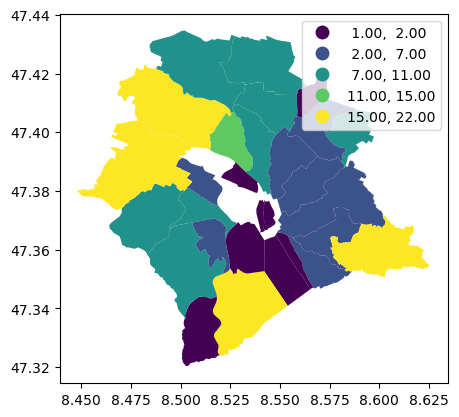

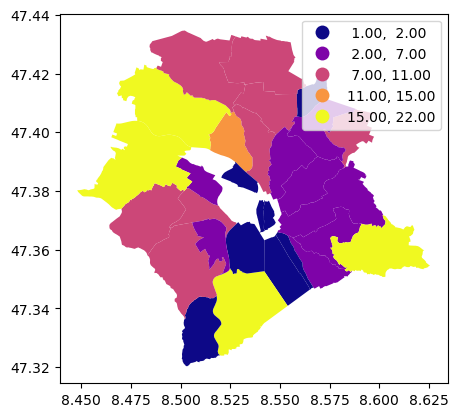

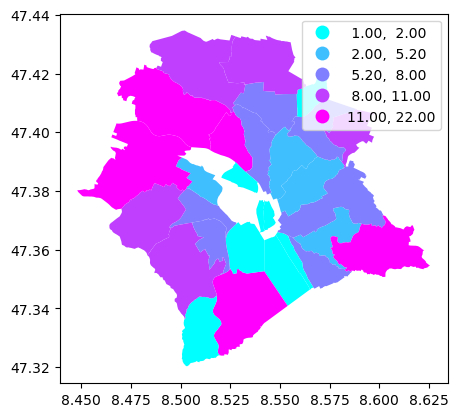

In [ ]:
# Plot by StatQuartiere
# Weitere Schemes: scheme='quantiles', scheme='fisherjenks', scheme='natural_breaks',

stadtquartiere_shapes_joined.plot(column='AnzSterWir', cmap='viridis', scheme='natural_breaks', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

stadtquartiere_shapes_joined.plot(column='AnzSterWir', cmap='plasma', scheme='fisherjenks', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html
stadtquartiere_shapes_joined.plot(column='AnzSterWir', cmap='cool', scheme='quantiles', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

#
#Neuere Gallerie: https://matplotlib.org/stable/gallery/index.html

Noch zu prüfen, folgendes schöne Beispiel: https://docs.bokeh.org/en/latest/docs/user_guide/interaction/legends.html

Konkrete Beispiele von Bookeh in Jupyter NB: https://docs.bokeh.org/en/latest/docs/user_guide/jupyter.html

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: 

- **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=554&e=JitFbH)**

- **[Früherer Link](http://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/EditForm.aspx?ID=157&Source=%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs)**